# Pipeline Smoke Test

Verifies that the environment, dataset, splits, dataloader, model, training loop,
checkpointing and Hugging Face connectivity all work before any real experiment starts.

**Attach the dataset first:** sidebar -> Add Input -> `shanmuk4622/tire-dataset-prepared`
**Accelerator:** GPU T4 x2 (works on single GPU too)
**Optional:** add `HF_TOKEN` under Add-ons -> Secrets to test the HF push

| Cell | What it does | Approx runtime |
|---|---|---|
| 1 | Environment + GPU check | 20 s |
| 2 | Locate dataset, integrity assertions | 20 s |
| 3 | Load manifests and splits | 10 s |
| 4 | Preview images | 15 s |
| 5 | Dataset + DataLoader | 5 s |
| 6 | Build model | 30 s |
| 7 | Train 3 epochs on fold 0 | 6-9 min |
| 8 | Validate + metrics | 30 s |
| 9 | Checkpoint save/load round-trip | 20 s |
| 10 | Hugging Face connectivity | 30 s |
| 11 | Final report | instant |

**Total: about 9-12 minutes.**

## Cell 1 — Environment and GPU

In [3]:
import os, sys, time, json, random, platform, subprocess, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

T0 = time.time()
CHECKS = {}
def check(name, ok, detail=""):
    CHECKS[name] = {"ok": bool(ok), "detail": str(detail)}
    print(("  PASS  " if ok else "  FAIL  ") + f"{name}" + (f"   {detail}" if detail else ""))
    return ok

print("python      ", sys.version.split()[0])
print("platform    ", platform.platform())

import numpy as np, pandas as pd
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)

import torch
print("torch       ", torch.__version__)
print("cuda build  ", torch.version.cuda)

cuda_ok = torch.cuda.is_available()
n_gpu = torch.cuda.device_count() if cuda_ok else 0
if cuda_ok:
    for i in range(n_gpu):
        p = torch.cuda.get_device_properties(i)
        print(f"gpu{i}        {p.name}  {p.total_memory/1e9:.1f} GB  cc{p.major}.{p.minor}")
check("cuda available", cuda_ok, f"{n_gpu} device(s)")

try:
    import timm; print("timm        ", timm.__version__); HAS_TIMM = True
except Exception:
    HAS_TIMM = False; print("timm         not installed - will use torchvision")

try:
    import sklearn; print("sklearn     ", sklearn.__version__)
except Exception:
    print("sklearn      not installed")

DEV = torch.device("cuda" if cuda_ok else "cpu")
print("\ndevice      ", DEV)

SEED = 1
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
print("seed        ", SEED)

for d in ["/kaggle/working", "/kaggle/temp"]:
    if os.path.exists(d):
        st = os.statvfs(d)
        print(f"{d:<18} free {st.f_bavail*st.f_frsize/1e9:6.1f} GB")
print(f"\ncell 1 done in {time.time()-T0:.1f}s")

python       3.12.13
platform     Linux-6.12.90+-x86_64-with-glibc2.35
numpy        2.0.2
pandas       2.3.3
torch        2.10.0+cu128
cuda build   12.8
gpu0        Tesla T4  15.6 GB  cc7.5
gpu1        Tesla T4  15.6 GB  cc7.5
  PASS  cuda available   2 device(s)
timm         1.0.26
sklearn      1.6.1

device       cuda
seed         1
/kaggle/working    free   20.9 GB

cell 1 done in 0.0s


## Cell 2 — Locate the dataset and check integrity

In [4]:
t = time.time()

def find_root(base="/kaggle/input"):
    """Kaggle sometimes wraps the upload in an extra directory. Find the real root."""
    base = Path(base)
    if not base.exists():
        return None
    for p in [base] + [q for q in base.rglob("*") if q.is_dir()]:
        if (p/"images").is_dir() and (p/"splits").is_dir() and (p/"manifests").is_dir():
            return p
    return None

ROOT = find_root()
print("dataset root:", ROOT)
if ROOT is None:
    print("\n  Dataset not found. Sidebar -> Add Input -> shanmuk4622/tire-dataset-prepared")
check("dataset located", ROOT is not None, str(ROOT))
assert ROOT is not None, "attach the dataset and re-run"

for sub in ["images", "manifests", "splits", "provenance", "reports"]:
    check(f"dir: {sub}", (ROOT/sub).is_dir())

if (ROOT/"VERSION.json").exists():
    print("\nVERSION.json:")
    print(json.dumps(json.load(open(ROOT/"VERSION.json")), indent=2))

rep = ROOT/"reports"/"FINAL_VERIFICATION_REPORT.json"
if rep.exists():
    r = json.load(open(rep))
    check("verification status PASS", r.get("status") == "PASS", r.get("status"))

n_jpg = sum(1 for _ in (ROOT/"images").rglob("*.jpg"))
print(f"\nimage files on disk: {n_jpg}")
check("image count == 4598", n_jpg == 4598, n_jpg)

print(f"\ncell 2 done in {time.time()-t:.1f}s")

dataset root: /kaggle/input/datasets/shanmuk4622/tire-dataset-prepared/Tire Dataset Prepared/FINAL
  PASS  dataset located   /kaggle/input/datasets/shanmuk4622/tire-dataset-prepared/Tire Dataset Prepared/FINAL
  PASS  dir: images
  PASS  dir: manifests
  PASS  dir: splits
  PASS  dir: provenance
  PASS  dir: reports

VERSION.json:
{
  "dataset_name": "Single Tyre Front-Camera Dataset",
  "version": "final_v1",
  "created_date": "2026-08-26",
  "clean_images": 418,
  "synthetic_derivatives": 4180,
  "total_files": 4598,
  "provisional_session_groups": 12,
  "folds": 3,
  "target": "three-level mileage proxy",
  "not_a_target": "measured tread depth, safety, roadworthiness, or wheel alignment",
  "storage_methods": {
    "hardlink": 4598
  }
}
  PASS  verification status PASS   PASS

image files on disk: 4598
  PASS  image count == 4598   4598

cell 2 done in 4.8s


## Cell 3 — Manifests and splits

In [5]:
t = time.time()

def read_csv(p):
    df = pd.read_csv(p)
    df.columns = [c.lstrip("﻿") for c in df.columns]
    return df

FOLD = 0
train_df = read_csv(ROOT/f"splits/cv{FOLD}_train.csv")
valid_df = read_csv(ROOT/f"splits/cv{FOLD}_validation.csv")
clean_df = read_csv(ROOT/"manifests/clean_manifest.csv")

print(f"fold {FOLD}:  train {len(train_df)}   valid {len(valid_df)}")
print(f"clean manifest rows: {len(clean_df)}   sessions: {clean_df.session_group.nunique()}")

# The assertions that actually matter
ok_disjoint = set(train_df.session_group).isdisjoint(set(valid_df.session_group))
check("no session leakage train/val", ok_disjoint)

ok_clean_val = set(valid_df.image_kind) == {"clean_original"}
check("validation is clean originals only", ok_clean_val, sorted(set(valid_df.image_kind)))

sample = train_df.sample(min(200, len(train_df)), random_state=0)
ok_paths = sample.relative_path.map(lambda p: (ROOT/p).exists()).all()
check("sampled paths resolve", ok_paths)

print("\ntrain sessions:", sorted(set(train_df.session_group)))
print("valid sessions:", sorted(set(valid_df.session_group)))

print("\ntrain class counts:"); print(train_df.proxy_label.value_counts().to_string())
print("\nvalid class counts:"); print(valid_df.proxy_label.value_counts().to_string())
print("\ntrain image_kind:");   print(train_df.image_kind.value_counts().to_string())

CLASSES = ["low_mileage_proxy", "mid_mileage_proxy", "high_mileage_proxy"]
C2I = {c: i for i, c in enumerate(CLASSES)}
print("\nclass index map:", C2I)
print(f"\ncell 3 done in {time.time()-t:.1f}s")

fold 0:  train 2552   valid 186
clean manifest rows: 418   sessions: 12
  PASS  no session leakage train/val
  PASS  validation is clean originals only   ['clean_original']
  PASS  sampled paths resolve

train sessions: ['mileage_000100_005000__session_001', 'mileage_000100_005000__session_002', 'mileage_040000__session_001', 'mileage_070000__session_001', 'mileage_100000_plus__session_001', 'mileage_100000_plus__session_003', 'mileage_100000_plus__session_005', 'mileage_100000_plus__session_006']
valid sessions: ['mileage_090000__session_001', 'mileage_100000_plus__session_002', 'mileage_100000_plus__session_004', 'new_tire__session_001']

train class counts:
proxy_label
low_mileage_proxy     1122
high_mileage_proxy     990
mid_mileage_proxy      440

valid class counts:
proxy_label
low_mileage_proxy     67
high_mileage_proxy    62
mid_mileage_proxy     57

train image_kind:
image_kind
synthetic_derivative    2320
clean_original           232

class index map: {'low_mileage_proxy': 0,

## Cell 4 — Preview a few images

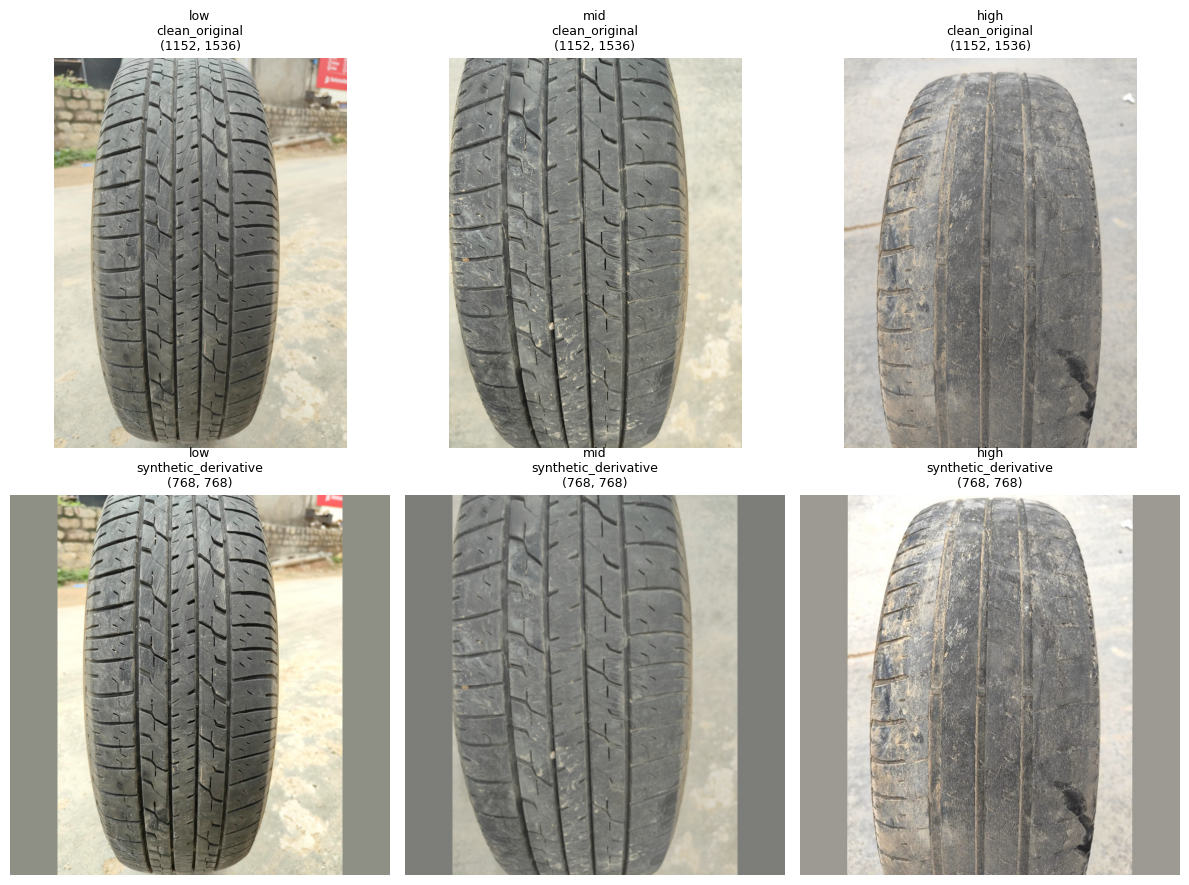

  PASS  images decode and display   6 shown
cell 4 done in 1.1s


In [6]:
t = time.time()
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 3, figsize=(12, 9))
shown = 0
for cls in CLASSES:
    for kind, ax in zip(["clean_original", "synthetic_derivative"], [axes[0], axes[1]]):
        sub = train_df[(train_df.proxy_label == cls) & (train_df.image_kind == kind)]
        if len(sub) == 0:
            sub = valid_df[valid_df.proxy_label == cls]
        if len(sub) == 0:
            continue
        row = sub.iloc[0]
        im = Image.open(ROOT/row.relative_path)
        col = CLASSES.index(cls)
        ax[col].imshow(im); ax[col].axis("off")
        ax[col].set_title(f"{cls.replace('_mileage_proxy','')}\n{kind}\n{im.size}", fontsize=9)
        shown += 1
plt.tight_layout(); plt.show()
check("images decode and display", shown > 0, f"{shown} shown")
print(f"cell 4 done in {time.time()-t:.1f}s")

## Cell 5 — Dataset and DataLoader

In [7]:
t = time.time()
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T

IMG_SIZE  = 224          # small for the smoke test; the real study sweeps 224-768
BATCH     = 32
N_WORKERS = 2

MEAN = [0.485, 0.456, 0.406]; STD = [0.229, 0.224, 0.225]

train_tf = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(), T.Normalize(MEAN, STD)])
valid_tf = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(), T.Normalize(MEAN, STD)])
# NOTE: no stochastic augmentation anywhere - derivatives are pre-generated,
# and validation must never be augmented.

class TyreDS(Dataset):
    def __init__(self, df, root, tf):
        self.df = df.reset_index(drop=True); self.root = Path(root); self.tf = tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(self.root/r.relative_path).convert("RGB")
        return self.tf(img), C2I[r.proxy_label], i

train_ds = TyreDS(train_df, ROOT, train_tf)
valid_ds = TyreDS(valid_df, ROOT, valid_tf)

# the dataset ships a sampling weight that balances class AND session
w = train_df["class_session_balanced_weight"].astype(float).values
sampler = WeightedRandomSampler(torch.as_tensor(w, dtype=torch.double), len(w), replacement=True)

train_dl = DataLoader(train_ds, batch_size=BATCH, sampler=sampler,
                      num_workers=N_WORKERS, pin_memory=True, drop_last=True, persistent_workers=True)
valid_dl = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                      num_workers=N_WORKERS, pin_memory=True)

xb, yb, _ = next(iter(train_dl))
print("batch  x:", tuple(xb.shape), xb.dtype, f"[{xb.min():.2f}, {xb.max():.2f}]")
print("batch  y:", tuple(yb.shape), yb.tolist()[:12])
check("dataloader yields a batch", xb.shape[0] == BATCH and xb.shape[1] == 3)
print(f"\ntrain batches {len(train_dl)}   valid batches {len(valid_dl)}")
print(f"cell 5 done in {time.time()-t:.1f}s")

batch  x: (32, 3, 224, 224) torch.float32 [-2.03, 2.61]
batch  y: (32,) [0, 0, 0, 2, 2, 1, 0, 2, 1, 2, 0, 0]
  PASS  dataloader yields a batch

train batches 79   valid batches 6
cell 5 done in 1.2s


## Cell 6 — Build the model

In [8]:
t = time.time()
import torch.nn as nn

ARCH = "resnet18"
if HAS_TIMM:
    model = timm.create_model(ARCH, pretrained=True, num_classes=len(CLASSES))
    src = "timm"
else:
    import torchvision.models as tvm
    model = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    src = "torchvision"

model = model.to(DEV).to(memory_format=torch.channels_last)
n_all = sum(p.numel() for p in model.parameters())
n_tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{ARCH} from {src}   params {n_all/1e6:.2f} M   trainable {n_tr/1e6:.2f} M")

with torch.no_grad():
    out = model(xb[:2].to(DEV).to(memory_format=torch.channels_last))
print("forward output:", tuple(out.shape))
check("model forward works", out.shape == (2, len(CLASSES)))

crit   = nn.CrossEntropyLoss(label_smoothing=0.05)
opt    = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
EPOCHS = 3
sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS*len(train_dl))
scaler = torch.cuda.amp.GradScaler(enabled=cuda_ok)   # fp16: T4 has no bf16
print(f"optimiser AdamW  lr 3e-4  epochs {EPOCHS}  amp {cuda_ok}")
print(f"cell 6 done in {time.time()-t:.1f}s")

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

resnet18 from timm   params 11.18 M   trainable 11.18 M
forward output: (2, 3)
  PASS  model forward works
optimiser AdamW  lr 3e-4  epochs 3  amp True
cell 6 done in 5.9s


## Cell 7 — Train

3 epochs on fold 0. **This is a smoke test, not a result** — the numbers here mean nothing.

In [9]:
t = time.time()

def gpu_stats():
    if not cuda_ok: return {}
    s = {}
    for i in range(n_gpu):
        s[f"gpu{i}_mem_alloc_mb"] = torch.cuda.memory_allocated(i)/1e6
        s[f"gpu{i}_mem_peak_mb"]  = torch.cuda.max_memory_allocated(i)/1e6
    return s

history = []
for ep in range(EPOCHS):
    ep_t = time.time(); model.train()
    run_loss = run_correct = run_n = 0
    data_t = 0.0; last = time.time()

    for step, (x, y, _) in enumerate(train_dl):
        data_t += time.time() - last
        x = x.to(DEV, non_blocking=True).to(memory_format=torch.channels_last)
        y = y.to(DEV, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=cuda_ok):
            logits = model(x); loss = crit(logits, y)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        gnorm = torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(opt); scaler.update(); sched.step()

        run_loss    += loss.item() * y.size(0)
        run_correct += (logits.argmax(1) == y).sum().item()
        run_n       += y.size(0)

        if step % 20 == 0:
            print(f"  ep{ep+1} step {step:>3}/{len(train_dl)}  loss {loss.item():.4f}  "
                  f"gnorm {gnorm:.2f}  lr {sched.get_last_lr()[0]:.2e}")
        last = time.time()

    ep_s = time.time() - ep_t
    rec = {"epoch": ep+1, "train_loss": run_loss/run_n, "train_acc": run_correct/run_n,
           "epoch_seconds": ep_s, "dataload_frac": data_t/ep_s,
           "amp_scale": float(scaler.get_scale()) if cuda_ok else None, **gpu_stats()}
    history.append(rec)
    print(f"epoch {ep+1}/{EPOCHS}  loss {rec['train_loss']:.4f}  acc {rec['train_acc']:.3f}  "
          f"{ep_s:.1f}s  dataload_frac {rec['dataload_frac']:.2f}")

hist_df = pd.DataFrame(history)
print("\n", hist_df.to_string(index=False))
check("training completed", len(history) == EPOCHS)
check("loss is finite", np.isfinite(hist_df.train_loss).all())
print(f"\ncell 7 done in {time.time()-t:.1f}s")

  ep1 step   0/79  loss 1.0928  gnorm 1.53  lr 3.00e-04
  ep1 step  20/79  loss 0.4136  gnorm 0.94  lr 2.94e-04
  ep1 step  40/79  loss 0.2541  gnorm 0.87  lr 2.78e-04
  ep1 step  60/79  loss 0.1946  gnorm 0.54  lr 2.54e-04
epoch 1/3  loss 0.3636  acc 0.965  34.0s  dataload_frac 0.75
  ep2 step   0/79  loss 0.1831  gnorm 0.29  lr 2.23e-04
  ep2 step  20/79  loss 0.1770  gnorm 0.18  lr 1.86e-04
  ep2 step  40/79  loss 0.1728  gnorm 0.09  lr 1.47e-04
  ep2 step  60/79  loss 0.1742  gnorm 0.15  lr 1.08e-04
epoch 2/3  loss 0.1793  acc 1.000  30.7s  dataload_frac 0.89
  ep3 step   0/79  loss 0.1823  gnorm 0.33  lr 7.33e-05
  ep3 step  20/79  loss 0.1799  gnorm 0.26  lr 4.22e-05
  ep3 step  40/79  loss 0.1787  gnorm 0.23  lr 1.86e-05
  ep3 step  60/79  loss 0.1724  gnorm 0.07  lr 4.25e-06
epoch 3/3  loss 0.1769  acc 1.000  29.7s  dataload_frac 0.88

  epoch  train_loss  train_acc  epoch_seconds  dataload_frac  amp_scale  gpu0_mem_alloc_mb  gpu0_mem_peak_mb  gpu1_mem_alloc_mb  gpu1_mem_peak_m

## Cell 8 — Validate

In [10]:
t = time.time()
model.eval()
all_p, all_y, all_prob = [], [], []
with torch.no_grad():
    for x, y, _ in valid_dl:
        x = x.to(DEV).to(memory_format=torch.channels_last)
        with torch.cuda.amp.autocast(enabled=cuda_ok):
            logits = model(x)
        prob = logits.float().softmax(1).cpu().numpy()
        all_prob.append(prob); all_p.append(prob.argmax(1)); all_y.append(y.numpy())

y_pred = np.concatenate(all_p); y_true = np.concatenate(all_y)
probs  = np.concatenate(all_prob)

acc = (y_pred == y_true).mean()
cm  = np.zeros((3, 3), int)
for a, b in zip(y_true, y_pred): cm[a, b] += 1

f1s = []
for k in range(3):
    tp = cm[k, k]; fp = cm[:, k].sum()-tp; fn = cm[k, :].sum()-tp
    pr = tp/(tp+fp) if tp+fp else 0.0
    rc = tp/(tp+fn) if tp+fn else 0.0
    f1s.append(2*pr*rc/(pr+rc) if pr+rc else 0.0)

# quadratic weighted kappa - the classes are ORDERED
def qwk(a, b, n=3):
    O = np.zeros((n, n)); 
    for i, j in zip(a, b): O[i, j] += 1
    W = np.array([[(i-j)**2/((n-1)**2) for j in range(n)] for i in range(n)])
    ha = np.bincount(a, minlength=n); hb = np.bincount(b, minlength=n)
    E = np.outer(ha, hb) / len(a)
    E = E * O.sum() / E.sum()
    return 1 - (W*O).sum()/max((W*E).sum(), 1e-9)

print(f"accuracy   {acc:.4f}")
print(f"macro F1   {np.mean(f1s):.4f}   per class {[round(f,3) for f in f1s]}")
print(f"QWK        {qwk(y_true, y_pred):.4f}")
print(f"MAE class  {np.abs(y_true-y_pred).mean():.4f}")
print(f"\nconfusion (rows = true low/mid/high):\n{cm}")

# per-session breakdown - this is how single-tyre memorisation shows up
vd = valid_df.reset_index(drop=True).copy()
vd["pred"] = y_pred; vd["true"] = y_true
print("\nper-session accuracy:")
print(vd.assign(ok=vd.pred == vd.true).groupby("session_group")
        .agg(n=("ok", "size"), acc=("ok", "mean")).round(3).to_string())

check("validation ran", len(y_pred) == len(valid_df))
print("\nNote: 3 epochs on one fold. These numbers are a smoke test, not a result.")
print(f"cell 8 done in {time.time()-t:.1f}s")

accuracy   1.0000
macro F1   1.0000   per class [np.float64(1.0), np.float64(1.0), np.float64(1.0)]
QWK        1.0000
MAE class  0.0000

confusion (rows = true low/mid/high):
[[67  0  0]
 [ 0 57  0]
 [ 0  0 62]]

per-session accuracy:
                                   n  acc
session_group                            
mileage_090000__session_001       57  1.0
mileage_100000_plus__session_002   2  1.0
mileage_100000_plus__session_004  60  1.0
new_tire__session_001             67  1.0
  PASS  validation ran

Note: 3 epochs on one fold. These numbers are a smoke test, not a result.
cell 8 done in 3.8s


## Cell 9 — Checkpoint save / load round-trip

In [11]:
t = time.time()
CKPT_DIR = Path("/kaggle/working/ckpt"); CKPT_DIR.mkdir(parents=True, exist_ok=True)
ckpt_path = CKPT_DIR/"smoke_test.pt"

state = {
    "epoch": EPOCHS,
    "model": model.state_dict(),
    "optimizer": opt.state_dict(),
    "scheduler": sched.state_dict(),
    "scaler": scaler.state_dict(),
    "rng": {
        "python": random.getstate(),
        "numpy":  np.random.get_state(),
        "torch":  torch.get_rng_state(),
        "cuda":   torch.cuda.get_rng_state_all() if cuda_ok else None,
    },
    "config": {"arch": ARCH, "img_size": IMG_SIZE, "batch": BATCH, "fold": FOLD, "seed": SEED},
    "metrics": {"val_acc": float(acc), "val_qwk": float(qwk(y_true, y_pred))},
    "classes": CLASSES,
    "torch_version": torch.__version__,
}

tmp = ckpt_path.with_suffix(".tmp")
torch.save(state, tmp); os.replace(tmp, ckpt_path)      # atomic
size_mb = ckpt_path.stat().st_size/1e6
print(f"saved {ckpt_path}  ({size_mb:.1f} MB)")

loaded = torch.load(ckpt_path, map_location="cpu", weights_only=False)
same = all(torch.equal(state["model"][k].cpu(), loaded["model"][k]) for k in state["model"])
check("checkpoint round-trips", same, f"{size_mb:.1f} MB")
print("keys:", sorted(loaded.keys()))
print(f"cell 9 done in {time.time()-t:.1f}s")

saved /kaggle/working/ckpt/smoke_test.pt  (134.3 MB)
  PASS  checkpoint round-trips   134.3 MB
keys: ['classes', 'config', 'epoch', 'metrics', 'model', 'optimizer', 'rng', 'scaler', 'scheduler', 'torch_version']
cell 9 done in 0.3s


## Cell 10 — Hugging Face connectivity (optional)

Skipped automatically if `HF_TOKEN` is not set. Add it under **Add-ons -> Secrets**.

In [12]:
t = time.time()
HF_USER = "Shanmuk4622"
HF_REPO = f"{HF_USER}/tyre-smoke-test"

token = None
try:
    from kaggle_secrets import UserSecretsClient
    token = UserSecretsClient().get_secret("HF_TOKEN")
    print("HF_TOKEN found in Kaggle secrets")
except Exception as e:
    print("HF_TOKEN not available:", type(e).__name__)

if not token:
    print("skipping HF test")
    CHECKS["hugging face push"] = {"ok": None, "detail": "skipped - no token"}
else:
    try:
        from huggingface_hub import HfApi, CommitOperationAdd
        api = HfApi(token=token)
        who = api.whoami()
        print("authenticated as:", who.get("name"))

        api.create_repo(HF_REPO, repo_type="dataset", exist_ok=True, private=True)

        probe = Path("/kaggle/working/probe.json")
        probe.write_text(json.dumps({
            "test": "smoke", "ts": time.time(),
            "val_acc": float(acc), "epochs": EPOCHS, "arch": ARCH}, indent=2))

        # one commit for many files = ONE rate-limit operation
        api.create_commit(
            repo_id=HF_REPO, repo_type="dataset",
            operations=[CommitOperationAdd("smoke/probe.json", str(probe))],
            commit_message="smoke test probe")

        files = api.list_repo_files(HF_REPO, repo_type="dataset")   # verify by re-listing
        check("hugging face push", "smoke/probe.json" in files, f"{len(files)} files in repo")
    except Exception as e:
        check("hugging face push", False, f"{type(e).__name__}: {e}")

print(f"cell 10 done in {time.time()-t:.1f}s")

HF_TOKEN found in Kaggle secrets
authenticated as: Shanmuk4622
  PASS  hugging face push   2 files in repo
cell 10 done in 2.2s


## Cell 11 — Report

In [13]:
print("="*62)
print("SMOKE TEST REPORT")
print("="*62)
n_pass = n_fail = n_skip = 0
for k, v in CHECKS.items():
    if v["ok"] is None:
        mark = "SKIP"; n_skip += 1
    elif v["ok"]:
        mark = "PASS"; n_pass += 1
    else:
        mark = "FAIL"; n_fail += 1
    print(f"  [{mark}]  {k:<38} {v['detail']}")
print("-"*62)
print(f"  {n_pass} passed   {n_fail} failed   {n_skip} skipped")
print(f"  total notebook runtime: {(time.time()-T0)/60:.1f} min")
print("="*62)
if n_fail == 0:
    print("\nAll checks passed. The pipeline is wired correctly.")
else:
    print(f"\n{n_fail} check(s) failed - see above.")

SMOKE TEST REPORT
  [PASS]  cuda available                         2 device(s)
  [PASS]  dataset located                        /kaggle/input/datasets/shanmuk4622/tire-dataset-prepared/Tire Dataset Prepared/FINAL
  [PASS]  dir: images                            
  [PASS]  dir: manifests                         
  [PASS]  dir: splits                            
  [PASS]  dir: provenance                        
  [PASS]  dir: reports                           
  [PASS]  verification status PASS               PASS
  [PASS]  image count == 4598                    4598
  [PASS]  no session leakage train/val           
  [PASS]  validation is clean originals only     ['clean_original']
  [PASS]  sampled paths resolve                  
  [PASS]  images decode and display              6 shown
  [PASS]  dataloader yields a batch              
  [PASS]  model forward works                    
  [PASS]  training completed                     
  [PASS]  loss is finite                         
  [P

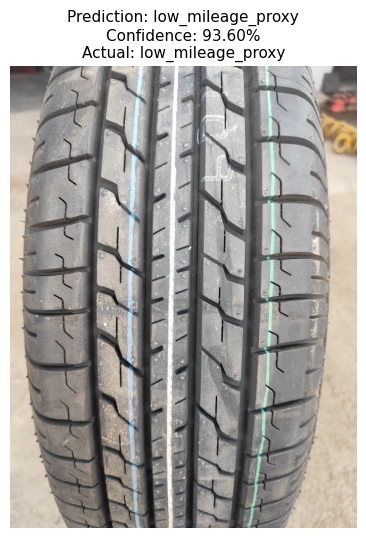

Class Probabilities:
  low_mileage_proxy   :  93.60%
  mid_mileage_proxy   :   2.86%
  high_mileage_proxy  :   3.54%


In [14]:
import torch
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

# 1. Define standard evaluation preprocessing
inference_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict_single_image(image_path, model, transform, classes, device):
    """Loads an image, runs model inference, and returns predicted class with probabilities."""
    # Load and convert image to RGB
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    # Perform prediction
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        pred_idx = torch.argmax(probabilities).item()
        
    pred_label = classes[pred_idx]
    confidence = probabilities[pred_idx].item()
    
    return img, pred_label, confidence, probabilities

# 2. Select a test image (e.g., sample from validation set or specify a custom path)
sample_row = valid_df.sample(1, random_state=42).iloc[0]
test_image_path = ROOT / sample_row.relative_path

# To use a custom uploaded image instead, uncomment and set path below:
# test_image_path = "/path/to/your/custom_tire_image.jpg"

# 3. Run prediction
img, pred_class, conf, all_probs = predict_single_image(
    test_image_path, model, inference_transform, CLASSES, DEV
)

# 4. Display the image and confidence results
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {pred_class}\nConfidence: {conf*100:.2f}%\nActual: {sample_row.proxy_label}", fontsize=11)
plt.show()

print("Class Probabilities:")
for cls, prob in zip(CLASSES, all_probs):
    print(f"  {cls:<20}: {prob.item()*100:6.2f}%")